# PharmaPulse — Data Analysis (M4)

Reads from the `metrics` schema built in `domains/pharma/dbt/models/metrics/` — no
recomputation of dbt logic here, this notebook only queries and visualizes.
7 data-driven insights, each with a supporting number and a chart. Written to be
reused as-is for the M5 Tableau dashboard and M6 executive memo.

**Known limitations carried from the metrics layer (see `decisions.md`):**
- `metric_phase_transition` groups by `condition_name`, not `therapeutic_area`
  (always NULL as of M3 — no MeSH crosswalk yet).
- CT.gov has no field linking a trial to its own phase-successor trial, so all
  three `metric_phase_transition` rate columns are relative-volume ratios, not
  true transition probabilities, and can exceed 100%. The Approval stage
  compounds this with a best-effort `sponsor_name` string match between CT.gov
  lead-sponsor names and FDA applicant names (different namespaces, no entity
  resolution). Insights 1 and 2 below quantify exactly how much this affects
  each stage.

In [1]:
import sys
sys.path.insert(0, "..")

from dotenv import load_dotenv
load_dotenv()

import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from core.extraction_runner import build_dsn

conn = psycopg.connect(build_dsn())


def q(sql: str) -> pd.DataFrame:
    """Read-only helper: runs a SELECT against the metrics schema, returns a DataFrame."""
    with conn.cursor() as cur:
        cur.execute(sql)
        cols = [desc[0] for desc in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)

In [2]:
# Palette from the dataviz skill's reference instance (references/palette.md),
# light mode. Categorical hues assigned in fixed order, never cycled.
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET, RED = (
    "#2a78d6", "#008300", "#e87ba4", "#eda100",
    "#1baf7a", "#eb6834", "#4a3aa7", "#e34948",
)
SURFACE = "#fcfcfb"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED_INK = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": SECONDARY_INK,
    "axes.titlecolor": PRIMARY_INK,
    "text.color": PRIMARY_INK,
    "xtick.color": MUTED_INK,
    "ytick.color": MUTED_INK,
    "grid.color": GRIDLINE,
    "font.size": 11,
})


def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(grid_axis != "x")
    ax.grid(axis=grid_axis, linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)

## Insight 1 — Phase 2→3 volume ratio varies widely by condition, and isn't a true conversion rate

Among conditions with at least 100 Phase-2 trials, `phase2_to_phase3_rate` (the
relative volume of Phase-3 vs. Phase-2 registrations for that condition) ranges
from 0% (Advanced Solid Tumors) up to 94.4% (Asthma) for the 95 conditions where
the ratio stays within a plausible 0–100% band. The other 14 of 109 conditions
(12.8%) show a ratio *above* 100% (e.g. Diabetes at 203%) — direct proof that
this is a cross-sectional volume ratio, not a followed cohort's transition
probability, since CT.gov has no field linking a trial to its own
phase-successor trial. Those 14 are excluded from the chart below and reported
separately, not hidden.

14 of 109 conditions (12.8%) show phase2_to_phase3_rate > 100%
Within the valid 0-100% band: Asthma highest (94.4%), Advanced Solid Tumors lowest (0.0%)


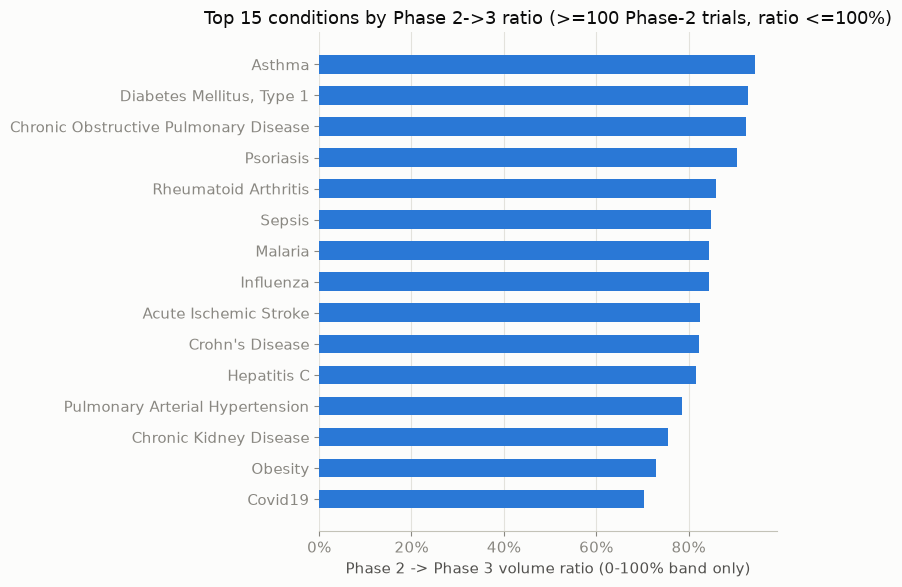

In [3]:
df1 = q("""
    select distinct condition_name, condition_phase2_trials, phase2_to_phase3_rate
    from metrics.metric_phase_transition
    where condition_phase2_trials >= 100
    order by phase2_to_phase3_rate desc
""")

over_100 = df1[df1["phase2_to_phase3_rate"] > 1]
valid = df1[df1["phase2_to_phase3_rate"] <= 1]
print(f"{len(over_100)} of {len(df1)} conditions ({len(over_100) / len(df1):.1%}) show phase2_to_phase3_rate > 100%")
print(f"Within the valid 0-100% band: {valid.iloc[0]['condition_name']} highest ({float(valid.iloc[0]['phase2_to_phase3_rate']):.1%}), "
      f"{valid.iloc[-1]['condition_name']} lowest ({float(valid.iloc[-1]['phase2_to_phase3_rate']):.1%})")

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = valid.sort_values("phase2_to_phase3_rate").tail(15)
ax.barh(plot_df["condition_name"], plot_df["phase2_to_phase3_rate"].astype(float), color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Phase 2 -> Phase 3 volume ratio (0-100% band only)")
ax.set_title("Top 15 conditions by Phase 2->3 ratio (>=100 Phase-2 trials, ratio <=100%)")
style_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## Insight 2 — The Approval-stage linkage is measurably noisy, on top of Insight 1's gap

`phase3_to_approval_rate` compounds Insight 1's cross-sectional-ratio issue with
a second, independent gap: the Approval stage is a best-effort `sponsor_name`
string match, not a trial-level link (CT.gov lead-sponsor names and FDA
applicant names are different namespaces — no entity resolution applied). 192
of 1,529 conditions with ≥5 Phase-3 trials (12.6%) show a rate *above* 100%,
which is only possible because the join is sponsor-level, not trial-level. Two
separate, independently-verified reasons the Approval stage should be read as
directional, not literal.

192 of 1529 conditions (12.6%) show phase3_to_approval_rate > 100%


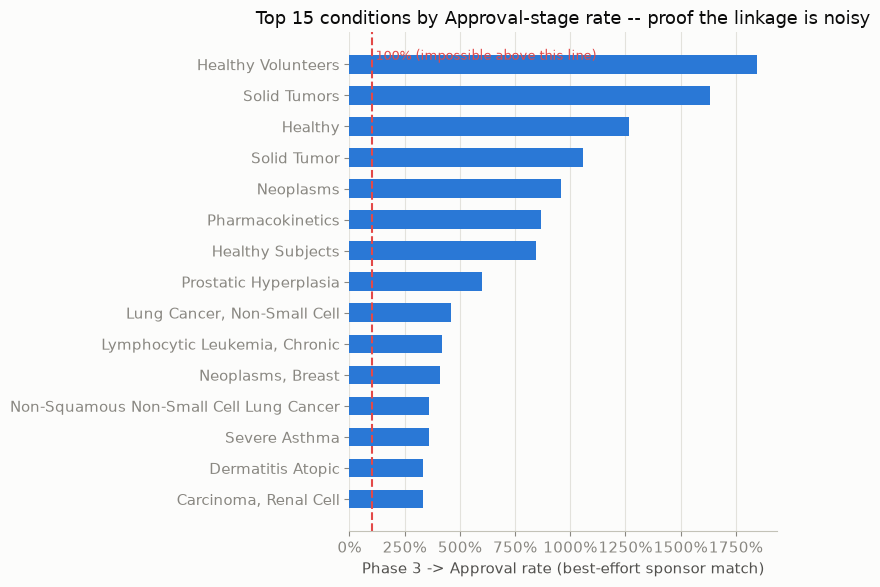

In [4]:
df2 = q("""
    select distinct condition_name, condition_phase3_trials, phase3_to_approval_rate
    from metrics.metric_phase_transition
    where condition_phase3_trials >= 5
    order by phase3_to_approval_rate desc
    limit 15
""")

over_100 = q("""
    select
        count(distinct condition_name) filter (where phase3_to_approval_rate > 1) as n_over,
        count(distinct condition_name) as n_total
    from metrics.metric_phase_transition
    where condition_phase3_trials >= 5
""")
n_over, n_total = int(over_100.iloc[0]["n_over"]), int(over_100.iloc[0]["n_total"])
print(f"{n_over} of {n_total} conditions ({n_over / n_total:.1%}) show phase3_to_approval_rate > 100%")

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = df2.sort_values("phase3_to_approval_rate")
ax.barh(plot_df["condition_name"], plot_df["phase3_to_approval_rate"].astype(float), color=BLUE, height=0.6)
ax.axvline(1.0, color=RED, linewidth=1.5, linestyle="--")
ax.text(1.0, len(plot_df) - 0.5, " 100% (impossible above this line)", color=RED, va="top", fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Phase 3 -> Approval rate (best-effort sponsor match)")
ax.set_title("Top 15 conditions by Approval-stage rate -- proof the linkage is noisy")
style_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## Insight 3 — Only ~5% of trials link to any FDA-matched sponsor

Of 594,309 trials, only 30,307 (5.1%) belong to a sponsor whose normalized name
matched an FDA applicant name in `fct_approvals`. This bounds how much of the
funnel's Approval stage is even observable today, independent of Insight 2's
noise finding — coverage and accuracy are two separate problems, both real.

Matched to an FDA sponsor: 30,307 of 594,309 trials (5.1%)


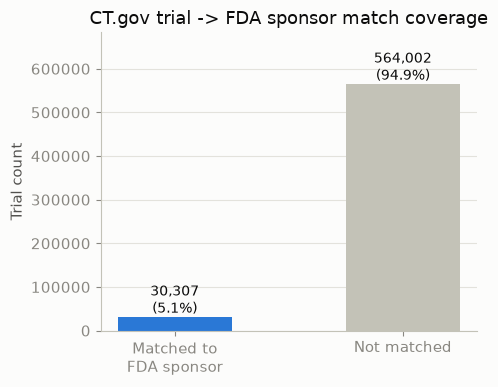

In [5]:
df3 = q("""
    select matched_to_fda, count(*) as trial_count
    from metrics.metric_phase_transition
    group by 1
    order by matched_to_fda desc
""")
total = int(df3["trial_count"].sum())
matched = int(df3.loc[df3["matched_to_fda"], "trial_count"].iloc[0])
print(f"Matched to an FDA sponsor: {matched:,} of {total:,} trials ({matched / total:.1%})")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Matched to\nFDA sponsor", "Not matched"]
values = [matched, total - matched]
colors = [BLUE, BASELINE]
bars = ax.bar(labels, values, color=colors, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({v / total:.1%})",
            ha="center", va="bottom", color=PRIMARY_INK, fontsize=10)
ax.set_ylabel("Trial count")
ax.set_title("CT.gov trial -> FDA sponsor match coverage")
ax.set_ylim(0, total * 1.15)
style_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()

## Insight 4 — Sponsor survivorship for the 2010 cohort decays fast, then levels off

Of the 1,560 sponsors who ran their first trial in 2010, 50.6% still had an
active trial five years later (2015), and 34.2% ten years later (2020). Most of
the drop-off happens in the first 5 years — the curve flattens after that.

2010 cohort survivorship: 50.6% at +5yr, 34.2% at +10yr


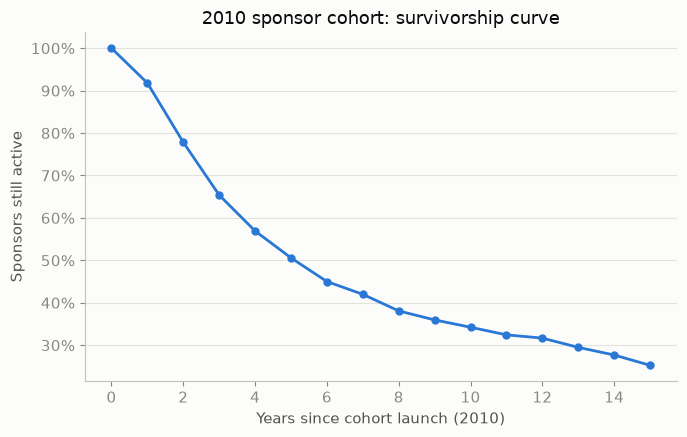

In [6]:
df4 = q("""
    select years_since_cohort, survivorship_rate
    from metrics.metric_sponsor_cohorts
    where cohort_year = 2010 and years_since_cohort <= 15
    order by years_since_cohort
""")
r5 = float(df4.loc[df4["years_since_cohort"] == 5, "survivorship_rate"].iloc[0])
r10 = float(df4.loc[df4["years_since_cohort"] == 10, "survivorship_rate"].iloc[0])
print(f"2010 cohort survivorship: {r5:.1%} at +5yr, {r10:.1%} at +10yr")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df4["years_since_cohort"], df4["survivorship_rate"].astype(float),
        color=BLUE, linewidth=2, marker="o", markersize=5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Years since cohort launch (2010)")
ax.set_ylabel("Sponsors still active")
ax.set_title("2010 sponsor cohort: survivorship curve")
style_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()

## Insight 5 — 5-year sponsor survivorship has fallen by half since 2000

Comparing cohorts at the same +5yr horizon: sponsors who entered in 2000 had
83.5% five-year survivorship; sponsors entering in 2019 had 40.5%. Newer sponsor
entrants persist in the trial ecosystem for markedly shorter windows than
sponsors from two decades ago.

2000 cohort +5yr survivorship: 83.5%
2019 cohort +5yr survivorship: 40.5%


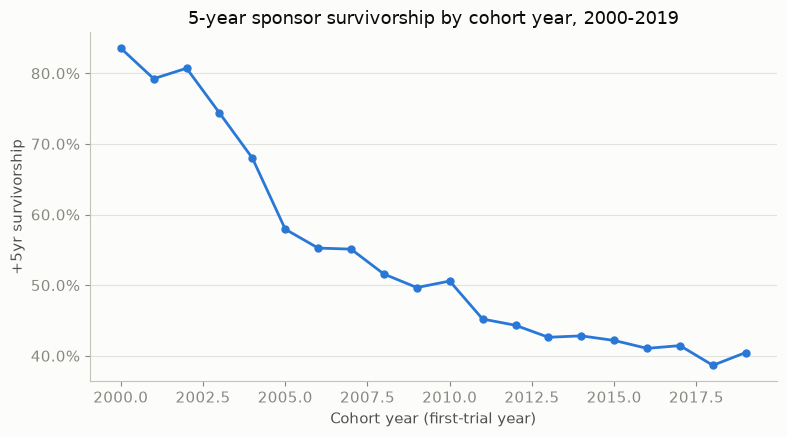

In [7]:
df5 = q("""
    select cohort_year, survivorship_rate
    from metrics.metric_sponsor_cohorts
    where years_since_cohort = 5 and cohort_year between 2000 and 2019
    order by cohort_year
""")
print(f"2000 cohort +5yr survivorship: {float(df5.iloc[0]['survivorship_rate']):.1%}")
print(f"2019 cohort +5yr survivorship: {float(df5.iloc[-1]['survivorship_rate']):.1%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df5["cohort_year"], df5["survivorship_rate"].astype(float),
        color=BLUE, linewidth=2, marker="o", markersize=5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Cohort year (first-trial year)")
ax.set_ylabel("+5yr survivorship")
ax.set_title("5-year sponsor survivorship by cohort year, 2000-2019")
style_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()

## Insight 6 — Registered trial volume grew ~268x from 1990 to 2020

Trials with a usable `start_date` grew from 125/year in 1990 to 16,787 in 2010
to 33,546 in 2020 — a 268x increase. Most of that reflects how sparse
early-1990s CT.gov registration was (the registry itself only launched in
2000; pre-2000 dates come from retrospectively-registered trials), on top of
real growth and ClinicalTrials.gov's own registration requirements tightening
over the period (FDAAA 2007 made registration mandatory for most drug/device
trials). The 1990-2000 comparison is a registry-coverage artifact, not a
clinical trend; growth from 2000 onward (1,932 -> 33,546, ~17x) is the more
readable trend.

1990: 125 trials -> 2020: 33,546 trials (268.4x)


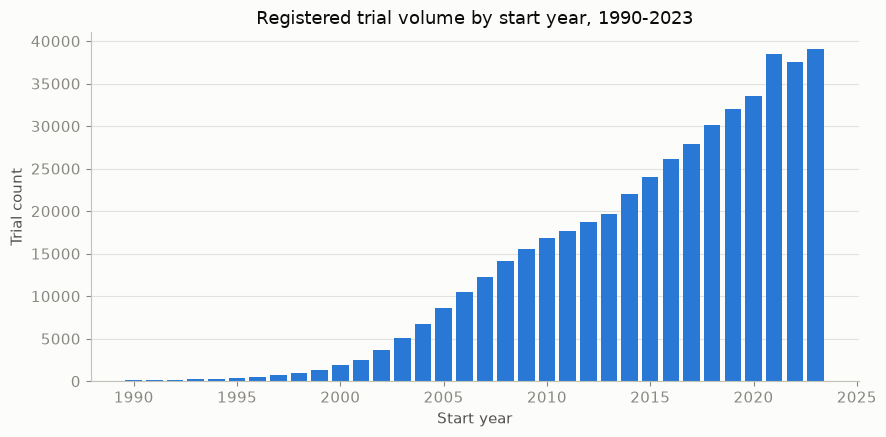

In [8]:
df6 = q("""
    select start_year, trial_count
    from metrics.metric_duration_trends
    where start_year between 1990 and 2023
    order by start_year
""")
c1990 = int(df6.loc[df6.start_year == 1990, "trial_count"].iloc[0])
c2020 = int(df6.loc[df6.start_year == 2020, "trial_count"].iloc[0])
print(f"1990: {c1990} trials -> 2020: {c2020:,} trials ({c2020 / c1990:.1f}x)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df6["start_year"], df6["trial_count"], color=BLUE, width=0.8)
ax.set_xlabel("Start year")
ax.set_ylabel("Trial count")
ax.set_title("Registered trial volume by start year, 1990-2023")
style_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()

## Insight 7 — Median trial duration appears to fall after ~2017 — but this is right-censoring, not real speed-up

Median `duration_days` by start_year drops from ~4,200 days (1990) to ~700 days
(2020). Read at face value this looks like trials getting dramatically faster.
It isn't (or isn't only that): `duration_days` requires a non-null
`completion_date`, and recent-year trials that are long-running are
disproportionately still enrolling/ongoing and so are excluded — only the
fast-completing trials from recent years have a duration to measure yet. The
last several years of this series (dashed) are not comparable to the earlier
solid segment. This caveat belongs in the M5/M6 deliverables alongside the
chart, not just in this notebook.

Median duration, 1990: 4361 days
Median duration, 2020: 700 days (right-censored zone, not comparable to 1990)


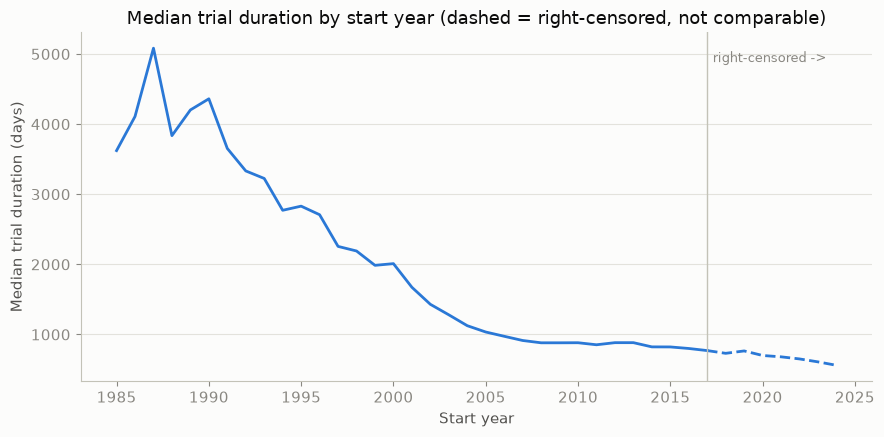

In [9]:
df7 = q("""
    select start_year, median_duration_days
    from metrics.metric_duration_trends
    where start_year between 1985 and 2024
    order by start_year
""")
CENSOR_CUTOFF = 2017  # last several years treated as right-censored, not comparable

reliable = df7[df7["start_year"] <= CENSOR_CUTOFF]
censored = df7[df7["start_year"] >= CENSOR_CUTOFF]

d1990 = float(df7.loc[df7.start_year == 1990, "median_duration_days"].iloc[0])
d2020 = float(df7.loc[df7.start_year == 2020, "median_duration_days"].iloc[0])
print(f"Median duration, 1990: {d1990:.0f} days")
print(f"Median duration, 2020: {d2020:.0f} days (right-censored zone, not comparable to 1990)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(reliable["start_year"], reliable["median_duration_days"].astype(float),
        color=BLUE, linewidth=2)
ax.plot(censored["start_year"], censored["median_duration_days"].astype(float),
        color=BLUE, linewidth=2, linestyle="--")
ax.axvline(CENSOR_CUTOFF, color=BASELINE, linewidth=1)
ax.text(CENSOR_CUTOFF + 0.3, ax.get_ylim()[1] * 0.92, "right-censored ->", color=MUTED_INK, fontsize=9)
ax.set_xlabel("Start year")
ax.set_ylabel("Median trial duration (days)")
ax.set_title("Median trial duration by start year (dashed = right-censored, not comparable)")
style_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()

## Summary — reusable findings for M5 (Tableau) / M6 (exec memo)

| # | Finding | Supporting number |
|---|---|---|
| 1 | Phase 2→3 volume ratio varies widely by condition, and 12.8% of conditions exceed the "100%" bound entirely (not a true transition probability) | 0% (Advanced Solid Tumors) to 94.4% (Asthma) in the valid band; 14/109 conditions over 100% |
| 2 | Approval-stage linkage is measurably noisy, independent of #1's gap | 192/1,529 conditions (12.6%) show a rate above 100% |
| 3 | Only ~5% of trials link to a matched FDA sponsor at all | 30,307 / 594,309 (5.1%) |
| 4 | 2010 sponsor cohort survivorship decays fast then flattens | 50.6% at +5yr, 34.2% at +10yr |
| 5 | 5-year sponsor survivorship has fallen by half since 2000 | 83.5% (2000 cohort) -> 40.5% (2019 cohort) |
| 6 | Registered trial volume grew ~268x, 1990-2020 (mostly registry-coverage artifact pre-2000; ~17x from 2000) | 125 -> 1,932 -> 16,787 -> 33,546 trials/year |
| 7 | Duration trend post-~2017 is right-censored, not a real speed-up | 4,200 -> 700 days at face value; caveat required in any downstream use |

In [10]:
conn.close()